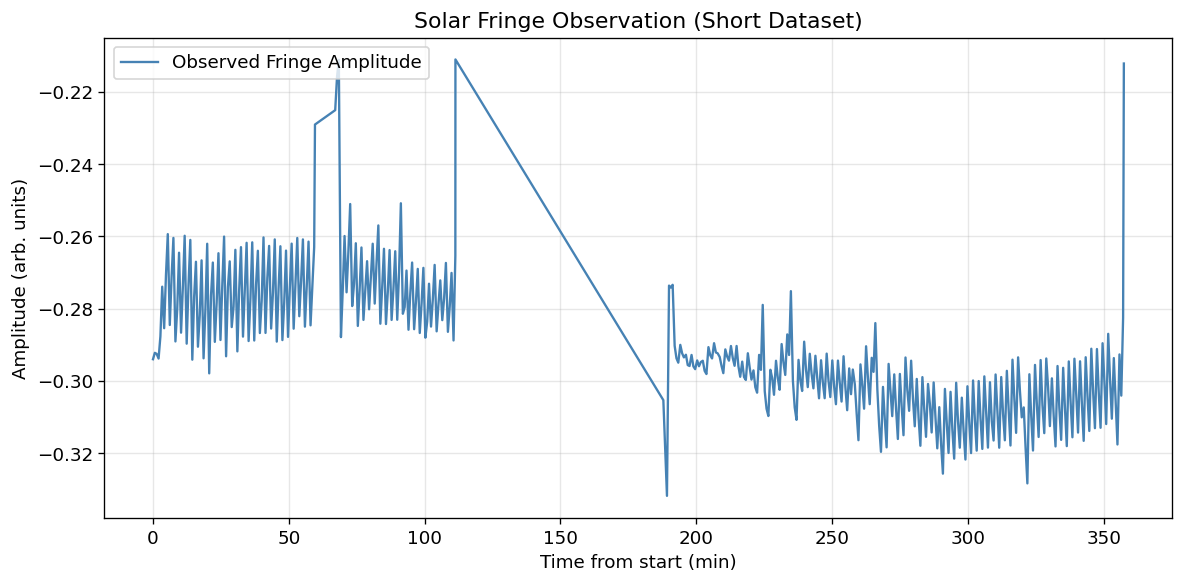

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import EarthLocation, get_sun
import astropy.units as u

# --- Load your .npz data ---
data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB3/DATA/RTFM_4_3_spectra.npz")

# --- Helper: Julian Date → Unix time ---
def jd_to_unix(jd_array):
    t = Time(jd_array, format='jd')
    return t.unix

# --- Helper: Compute hour angles ---
def compute_hour_angles(jd_array, lat, lon):
    t = Time(jd_array, format='jd', scale='utc')
    location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)
    sun_coord = get_sun(t)
    lst = t.sidereal_time('mean', longitude=location.lon)
    ha = (lst - sun_coord.ra).to(u.rad).value
    ha = (ha + np.pi) % (2*np.pi) - np.pi  # wrap between -π and π
    return ha

# --- Observatory & Sun parameters ---
lat = 37.0             # degrees
lon = -122.0           # degrees
delta = np.radians(23.0)  # Sun declination
b_ew = 20.0            # m
b_ns = 0.0             # m
lam = 0.025            # m (X-band wavelength)

# --- Prepare data ---
times = jd_to_unix(data['jd'])
ha = compute_hour_angles(data['jd'], lat, lon)
band_amp = np.mean(data['spec_real'], axis=1)  # band-averaged amplitude
dt_min = (times - times[0]) / 60  # minutes from start

# --- Plot observed fringes ---
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dt_min, band_amp, color='steelblue', label='Observed Fringe Amplitude')

ax.set_xlabel('Time from start (min)')
ax.set_ylabel('Amplitude (arb. units)')
ax.set_title('Solar Fringe Observation (Short Dataset)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [142]:
# --- Basic dataset metadata ---
num_observations = len(data['jd'])
num_channels = data['spec_real'].shape[1]  # number of frequency channels
time_start = Time(data['jd'][0], format='jd').iso
time_end   = Time(data['jd'][-1], format='jd').iso
total_duration_sec = (Time(data['jd'][-1], format='jd').unix -
                      Time(data['jd'][0], format='jd').unix)
integration_time_sec = total_duration_sec / num_observations
band_mean = np.mean(data['spec_real'])
band_std  = np.std(data['spec_real'])

# --- Print summary ---
print("=== Fringe Observation Summary ===")
print(f"Number of observations: {num_observations}")
print(f"Number of frequency channels: {num_channels}")
print(f"Observation start: {time_start} UTC")
print(f"Observation end:   {time_end} UTC")
print(f"Total duration:    {total_duration_sec:.1f} s ({total_duration_sec/60:.1f} min)")
print(f"Approx. integration time per sample: {integration_time_sec:.2f} s")
print(f"Band-averaged amplitude: mean = {band_mean:.3f}, std = {band_std:.3f}")

=== Fringe Observation Summary ===
Number of observations: 401
Number of frequency channels: 1024
Observation start: 2026-04-02 18:01:00.957 UTC
Observation end:   2026-04-02 23:58:23.314 UTC
Total duration:    21442.4 s (357.4 min)
Approx. integration time per sample: 53.47 s
Band-averaged amplitude: mean = -0.291, std = 0.450


In [143]:
import numpy as np
from astropy.time import Time
from datetime import datetime, timezone, timedelta

# --- Basic dataset metadata ---
num_observations = len(data['jd'])
num_channels = data['spec_real'].shape[1]  # number of frequency channels
time_start_utc = Time(data['jd'][0], format='jd').to_datetime(timezone.utc)
time_end_utc   = Time(data['jd'][-1], format='jd').to_datetime(timezone.utc)

# Convert to local time (example: Pacific Time = UTC-7 or UTC-8 depending on daylight)
utc_offset_hours = -7
time_start_local = time_start_utc + timedelta(hours=utc_offset_hours)
time_end_local   = time_end_utc   + timedelta(hours=utc_offset_hours)

total_duration_sec = (Time(data['jd'][-1], format='jd').unix -
                      Time(data['jd'][0], format='jd').unix)
integration_time_sec = total_duration_sec / num_observations
band_mean = np.mean(data['spec_real'])
band_std  = np.std(data['spec_real'])

# --- Print summary ---
print("=== Fringe Observation Summary ===")
print(f"Number of observations: {num_observations}")
print(f"Number of frequency channels: {num_channels}")
print(f"Observation start: {time_start_local.strftime('%I:%M:%S %p')} (local)")
print(f"Observation end:   {time_end_local.strftime('%I:%M:%S %p')} (local)")
print(f"Total duration:    {total_duration_sec:.1f} s ({total_duration_sec/60:.1f} min)")
print(f"Approx. integration time per sample: {integration_time_sec:.2f} s")
print(f"Band-averaged amplitude: mean = {band_mean:.3f}, std = {band_std:.3f}")

=== Fringe Observation Summary ===
Number of observations: 401
Number of frequency channels: 1024
Observation start: 11:01:00 AM (local)
Observation end:   04:58:23 PM (local)
Total duration:    21442.4 s (357.4 min)
Approx. integration time per sample: 53.47 s
Band-averaged amplitude: mean = -0.291, std = 0.450
